In [38]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage 
from langgraph.graph.message import add_messages # from langgraph.reducers import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [7]:
load_dotenv()

True

In [9]:
llm = ChatOpenAI() 

In [13]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

LangGraph knows that `message` should be appended/merged, rather than simply replaced. 

So the final state is conceptually:

```
messages
   │
   ├── HumanMessage
   │      "What is Object Oriented Programming?"
   │
   └── AIMessage
          "Object-oriented programming is..."
```

There are 3 important pieces here:

```
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
```
This defines **What data travels through the graph**.

```
def chat_node(state: ChatState):
```

This defines **What the node does with that data**.

```
return {"messages": [response]}
```

This defines **What data the node send back into the graph**.

In [26]:
def chat_node(state: ChatState):
    # take user query from state
    messages = state["messages"]
    # sent to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}

In [27]:
graph = StateGraph(ChatState) 

In [28]:
# Add nodes to the graph
graph.add_node('chat_node', chat_node)

In [29]:
# Add edges to the graph
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

In [30]:
chatbot = graph.compile()

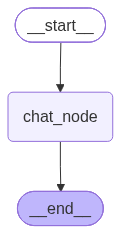

In [31]:
chatbot

In [21]:
initial_state = {
    'messages': [HumanMessage(content="What is Object Oriented Programming?")]
}

In [32]:
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is Object Oriented Programming?', additional_kwargs={}, response_metadata={}, id='c8367e6b-c1fb-4bf1-be88-136ca3c6b66a'),
  AIMessage(content='Object Oriented Programming (OOP) is a programming paradigm that uses "objects" to organize code rather than procedures and functions. In OOP, everything is represented as an object, which contains data and methods to manipulate that data. Objects are instances of classes, which are templates that define the properties and behaviors of objects.\n\nOOP allows for the encapsulation of data and behavior, making it easier to manage and reuse code. It also promotes modularity, making it easier to break down complex systems into smaller, more manageable pieces.\n\nSome key principles of OOP include inheritance, polymorphism, and encapsulation. Inheritance allows for the creation of new classes based on existing classes, polymorphism allows objects to take on different forms, and encapsulation restricts access t

In [33]:
response = chatbot.invoke(initial_state)

In [34]:
response

{'messages': [HumanMessage(content='What is Object Oriented Programming?', additional_kwargs={}, response_metadata={}, id='c8367e6b-c1fb-4bf1-be88-136ca3c6b66a'),
  AIMessage(content='Object-oriented programming (OOP) is a programming paradigm based on the concept of "objects," which can contain data in the form of fields (attributes or properties) and code in the form of procedures (methods or functions). Objects are instances of classes, which define the structure, behavior, and relationships of the objects.\n\nIn OOP, programs are organized around objects that interact with each other. This helps to modularize code, making it more reusable, maintainable, and scalable. OOP also promotes concepts like encapsulation, inheritance, and polymorphism, which help to increase code flexibility and reduce code duplication.\n\nSome common programming languages that support OOP include Java, C++, Python, and Ruby.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'complet

In [35]:
response['messages'][-1].content

'Object-oriented programming (OOP) is a programming paradigm based on the concept of "objects," which can contain data in the form of fields (attributes or properties) and code in the form of procedures (methods or functions). Objects are instances of classes, which define the structure, behavior, and relationships of the objects.\n\nIn OOP, programs are organized around objects that interact with each other. This helps to modularize code, making it more reusable, maintainable, and scalable. OOP also promotes concepts like encapsulation, inheritance, and polymorphism, which help to increase code flexibility and reduce code duplication.\n\nSome common programming languages that support OOP include Java, C++, Python, and Ruby.'

In [37]:
while True:
    user_message = input("Type here:")
    print('User:', user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting the chatbot. Goodbye!")
        break
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print('Bot:', response['messages'][-1].content)

User: Hi
Bot: Hello! How are you today?
User: my name is joe!
Bot: Hello Joe! How can I assist you today?
User: What is Python?
Bot: Python is a high-level programming language that is known for its simplicity and readability. It is used for a wide range of applications, including web development, data analysis, artificial intelligence, and scientific computing. Python's syntax allows for writing clean and concise code, making it a popular choice among developers of all skill levels.
User: what is my name?
Bot: I'm sorry, but I do not know your name as it was not provided.
User: exit
Exiting the chatbot. Goodbye!


#### Add memory using a checkpointer (Presistants)

```
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

chatbot = graph.compile(checkpointer=memory)
```


Now your graph becomes:
```
                thread_id = 1
                     │
                     ▼
              ┌─────────────┐
              │   Memory    │
              └──────┬──────┘
                     │
                     ▼
User ────────> Chat Node ────────> LLM
                     │
                     ▼
              Updated State
                     │
                     ▼
                  Memory
```

In [44]:
# Memory  
checkpoint = MemorySaver()

# State
graph = StateGraph(ChatState) 

# Add nodes to the graph
graph.add_node('chat_node', chat_node)

# Add edges to the graph
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpoint)

In [45]:
# Thread
thread_id = 1

# chatbot loop
while True:
    user_message = input("Type here:")
    print('User:', user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting the chatbot. Goodbye!")
        break
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('Bot:', response['messages'][-1].content)

User: Hi
Bot: Hello! How can I assist you today?
User: my name is joe!
Bot: Nice to meet you, Joe! How can I assist you today?
User: what is a AI agent?
Bot: An AI agent, also known as an artificial intelligence agent, is a software program that can perform tasks or services for humans autonomously. These agents use artificial intelligence algorithms to analyze data, make decisions, and take actions without direct human intervention. They are commonly used in various applications such as virtual assistants, chatbots, customer service, and more.
User: what is my name?
Bot: Your name is Joe.
User: bye
Exiting the chatbot. Goodbye!


In [50]:
thread_id = "1"
initial_state = {
    'messages': [HumanMessage(content="What is my name?")]
}
config = {'configurable': {'thread_id': thread_id}}
response = chatbot.invoke(initial_state, config=config)


In [49]:
response['messages'][-1].content

'Nice to meet you, John! How can I assist you today?'

In [51]:
response['messages'][-1].content

'Your name is John.'

In [52]:
thread_id = "2"
initial_state = {
    'messages': [HumanMessage(content="What is my name?")]
}
config = {'configurable': {'thread_id': thread_id}}
response = chatbot.invoke(initial_state, config=config)

In [53]:
response['messages'][-1].content

"I'm sorry, I do not have that information."

In [54]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='b8f742a7-6ef9-4c76-97d8-356b8783904c'), AIMessage(content="I'm sorry, I do not have that information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 12, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EUsu0tGHhq62qdlMSJQA8T5BF0zhm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a101ae-bd9f-7bf0-9256-c410f6296ac3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12